# <b> Part A

In [2]:
# Install if needed
# !pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = sns.load_dataset('titanic')

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 891
Number of Columns: 15


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features = df.select_dtypes(include=['object','category','bool']).columns

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')
Categorical Features: Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


# <b> Part B

In [9]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)

In [12]:
# Add new category first
df['deck'] = df['deck'].cat.add_categories(['Unknown'])

# Now fill missing values
df['deck'].fillna('Unknown', inplace=True)

In [13]:
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['deck'].fillna("Unknown", inplace=True)

In [14]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    2
alive          0
alone          0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(110)

In [16]:
df.drop_duplicates(inplace=True)

# <B> Part C

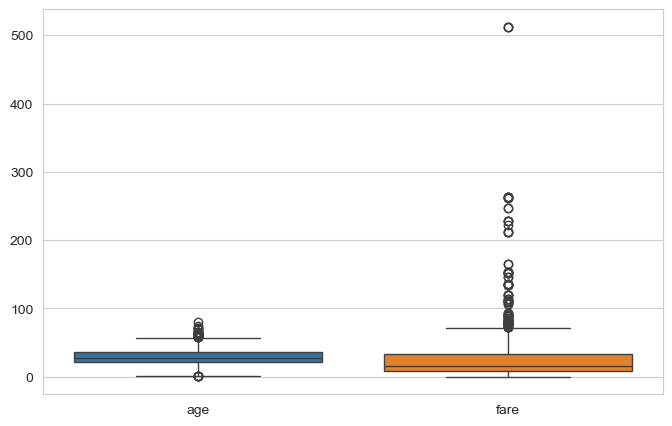

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['age','fare']])
plt.show()

In [18]:
Q1 = df[['age','fare']].quantile(0.25)
Q3 = df[['age','fare']].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[['age','fare']] < (Q1 - 1.5 * IQR)) |
          (df[['age','fare']] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age','fare']] = scaler.fit_transform(df[['age','fare']])

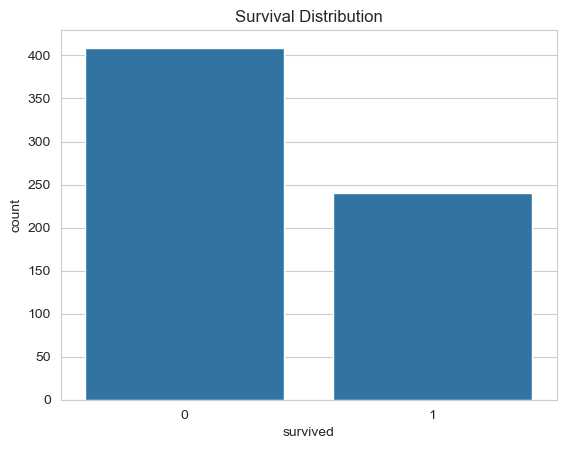

In [20]:
sns.countplot(x='survived', data=df)
plt.title("Survival Distribution")
plt.show()

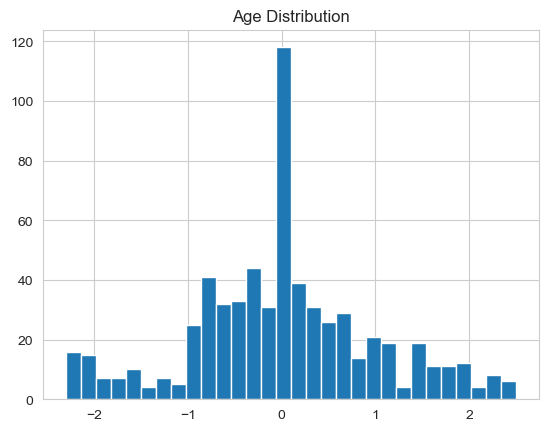

In [21]:
df['age'].hist(bins=30)
plt.title("Age Distribution")
plt.show()

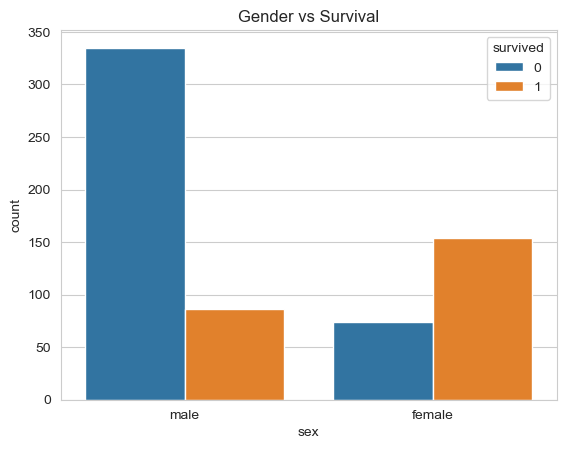

In [22]:
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Gender vs Survival")
plt.show()

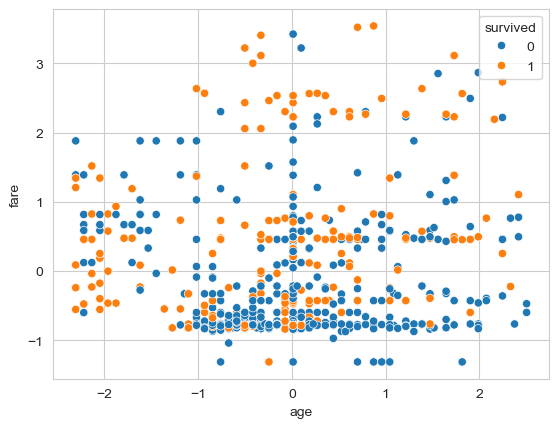

In [23]:
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.show()

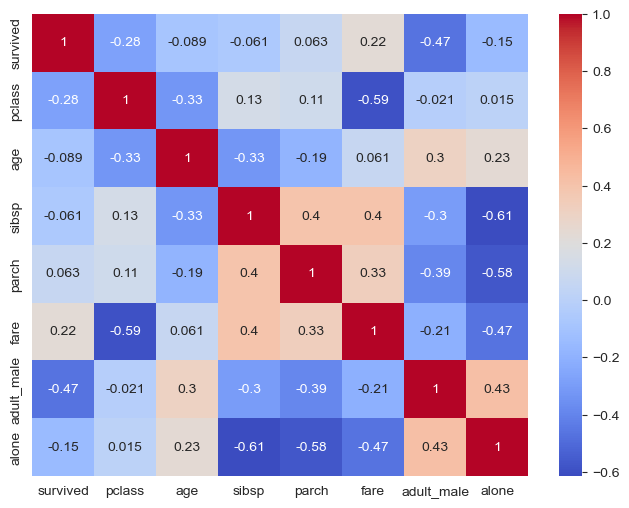

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

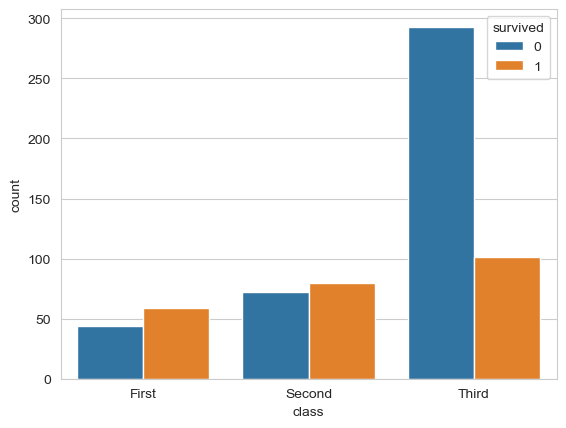

In [25]:
sns.countplot(x='class', hue='survived', data=df)
plt.show()

In [27]:
df.to_csv("cleaned_titanic_data.csv", index=False)